# Relative error vs code parameters (CPP experiments)

This notebook loads relative error CSVs from `/mnthdd/cpanourg/2-hdvc/results/relerr_cpp` and plots:

- Relative error vs **number of subquantizers**
- Relative error vs **bits per subvector (`nbits`)**
- Relative error vs **bits per vector**

Figures are styled similarly to those in `DARTH_plus_conformal.ipynb` (font sizes, figure sizes, and general aesthetics).

In [110]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogLocator

# --- Plot style (aligned with DARTH_plus_conformal.ipynb) ---
# Base style - will be overridden to font.size=40 for individual plots
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 21,
})
# plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path("/data/cpanourg/2-hdvc/results/relerr_cpp")
CSV_PATTERN = "*_adc_vs_exact_eval.csv"

In [111]:
from glob import glob

def load_relerr_data(data_dir: Path, pattern: str = CSV_PATTERN) -> pd.DataFrame:
    """Load and concatenate all relative-error CSVs in `data_dir`.

    Assumes filenames of the form `{dataset}_{method}_adc_vs_exact_eval.csv`.
    """
    csv_paths = sorted(data_dir.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f"No CSVs matching {pattern!r} found in {data_dir}")

    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path)

        # Infer dataset/method from filename if needed
        name = path.stem  # e.g., deep_OPQ_adc_vs_exact_eval
        parts = name.split("_")
        if len(parts) >= 2:
            file_dataset, file_method = parts[0], parts[1]
            if "dataset" not in df.columns:
                df["dataset"] = file_dataset
            if "method" not in df.columns:
                df["method"] = file_method
        dfs.append(df)

    all_df = pd.concat(dfs, ignore_index=True)

    # Ensure expected columns exist
    required_cols = [
        "method",
        "dataset",
        "n_subquantizers",
        "nbits",
        "bits_per_vector",
        "rel_error_mean",
        "rel_error_std",
    ]
    missing = [c for c in required_cols if c not in all_df.columns]
    if missing:
        raise ValueError(f"Missing columns in concatenated DF: {missing}")

    return all_df

relerr_df = load_relerr_data(DATA_DIR)
relerr_df.head()

# ============================================================================
# CONFIGURATION: Select methods, datasets, and x-axis columns to plot
# ============================================================================

# Select which methods to plot (available: OPQ, PQ)
METHODS_TO_PLOT = ["PQ", "OPQ"]  # Change to ["OPQ"] or ["PQ"] to plot only one

# Select which datasets to plot (available: deep, gist)
DATASETS_TO_PLOT = ["deep"] #, "bigann", "gist", "msmarco", "openai"]  # Change to ["deep"] or ["gist"] to plot only one

# Select which x-axis columns to plot (column_name, display_label)
# Available columns: n_subquantizers, nbits, bits_per_vector, train_time_s, or any other numeric column
X_COLUMNS_TO_PLOT = [
    ("n_subquantizers", "Num subq"),
    ("nbits", "nbits"),
    # ("bits_per_vector", "Bits per vector"),
    # ("train_time_s", "Training time (seconds)"),  # Relative error vs training time
    # ("adc_time_s", "ADC time (seconds)"),  # Relative error vs asymmetric distance computation time
    # ("distance_table_time_s", "Distance table time (seconds)"),  # Relative error vs distance table computation time
]

# You can also add custom columns, e.g.:
# X_COLUMNS_TO_PLOT = [
#     ("n_subquantizers", "Number of subquantizers"),
#     ("train_time_s", "Training time (seconds)"),
# ]

# Optional: Set y-axis limits for common x-axis columns
# Format: {column_name: (ymin, ymax)} or {column_name: None} to use auto
# This ensures all plots with the same x-axis have the same y-axis range for easy comparison
YLIM_CONFIG = {
    # "n_subquantizers": (0.0, 0.6),  # Example: set ylim for subquantizers plots
    # "nbits": (0.0, 0.3),             # Example: set ylim for nbits plots
    # "bits_per_vector": None,         # Use None or omit to use auto scaling
}

# Grouping configuration for bits_per_vector plots
# Options: "nbits" or "n_subquantizers"
# - "nbits": Groups by bits per subvector (shows how precision per subvector affects performance)
# - "n_subquantizers": Groups by number of subquantizers (shows trade-off between granularity and total bits)
BITS_PER_VECTOR_GROUPING = "nbits" # "n_subquantizers"  # Change to "nbits" to group by bits per subvector instead

# Additional plots with different y-axis columns
# Format: list of tuples (x_col, x_label, y_col, y_label, group_by)
# - x_col: Column name for x-axis
# - x_label: Display label for x-axis
# - y_col: Column name for y-axis (e.g., "adc_time_s", "rel_error_mean", "train_time_s")
# - y_label: Display label for y-axis (or None for auto-generated)
# - group_by: "nbits" or "n_subquantizers" - how to group the curves
ADDITIONAL_PLOTS = [
    # Plot ADC time vs number of subquantizers, grouped by nbits
    # ("n_subquantizers", "Num subq", "adc_time_s", "ADC time (seconds)", "nbits"),
    # Add more plots here as needed
    # ("bits_per_vector", "Bits per vector", "adc_time_s", "ADC time (seconds)", "nbits"),
    
    # Training time plots
    # ("n_subquantizers", "Num subq", "train_time_s", "Training time (seconds)", "nbits"),
    # ("nbits", "nbits", "train_time_s", "Training time (seconds)", "n_subquantizers"),
    # ("bits_per_vector", "Bits per vector", "train_time_s", "Training time (seconds)", "nbits"),
]

# Bar plots for timing metrics (bin-style plots) with averaging
# Format: list of tuples (x_col, x_label, y_col, y_label, group_by)
# - x_col: Column name for x-axis (will be grouped into bins/bars)
# - x_label: Display label for x-axis
# - y_col: Column name for y-axis (e.g. "train_time_s", "adc_time_s", "distance_table_time_s")
# - y_label: Display label for y-axis (or None for auto-generated)
# - group_by: "nbits" or "n_subquantizers" - dimension to average over (the legend dimension)
BAR_PLOTS = [
    # Training time bar plots (averaged over legend dimension)
    # Plot 1: Training time vs Num subq (averaged over nbits) - single bars per subq
    # ("n_subquantizers", "Num subq", "train_time_s", "Training time (seconds)", "nbits"),
    # Plot 2: Training time vs nbits (averaged over n_subquantizers) - single bars per nbits
    # ("nbits", "nbits", "train_time_s", "Training time (seconds)", "n_subquantizers"),

    # ADC time bar plots (averaged over legend dimension)
    # Plot 3: ADC time vs Num subq (averaged over nbits)
    # ("n_subquantizers", "Num subq", "adc_time_s", "ADC time (seconds)", "nbits"),
    # Plot 4: ADC time vs nbits (averaged over n_subquantizers)
    # ("nbits", "nbits", "adc_time_s", "ADC time (seconds)", "n_subquantizers"),

    # Distance table time bar plots (averaged over legend dimension)
    # Plot 5: Distance table time vs Num subq (averaged over nbits)
    # ("n_subquantizers", "Num subq", "distance_table_time_s", "Distance table time (seconds)", "nbits"),
    # Plot 6: Distance table time vs nbits (averaged over n_subquantizers)
    # ("nbits", "nbits", "distance_table_time_s", "Distance table time (seconds)", "n_subquantizers"),
]


Plotting: Relative error vs Num subq
Methods: ['PQ', 'OPQ'], Datasets: ['deep']

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/relerr_pq_deep_nsubquantizers.pdf


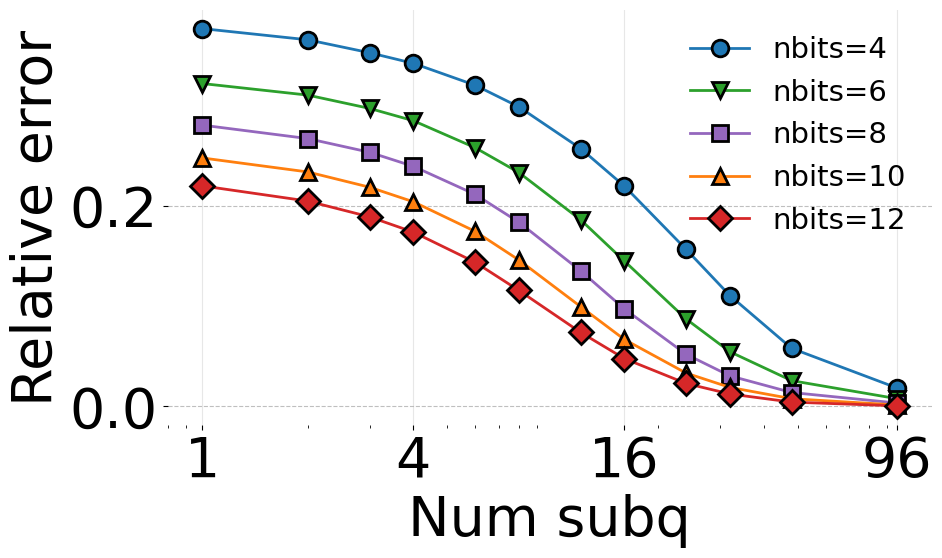

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/relerr_opq_deep_nsubquantizers.pdf


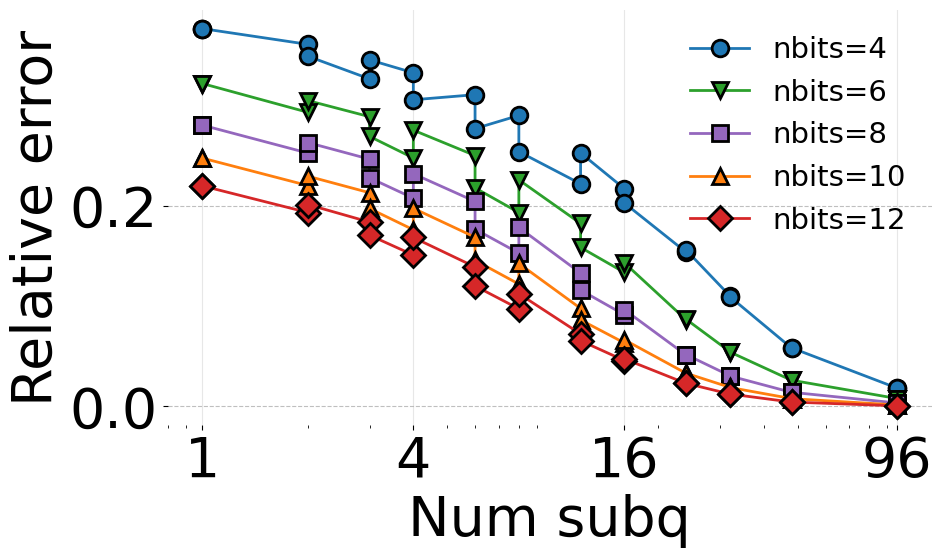


Plotting: Relative error vs nbits
Methods: ['PQ', 'OPQ'], Datasets: ['deep']

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/relerr_pq_deep_nbits.pdf


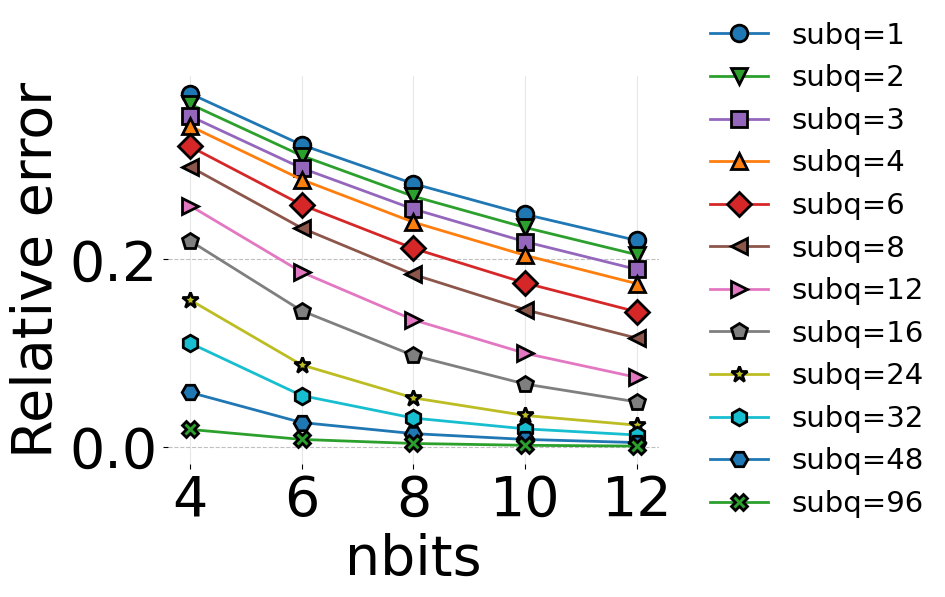

Saved figure to /data/cpanourg/2-hdvc/results/relerr_cpp/figures/relerr_opq_deep_nbits.pdf


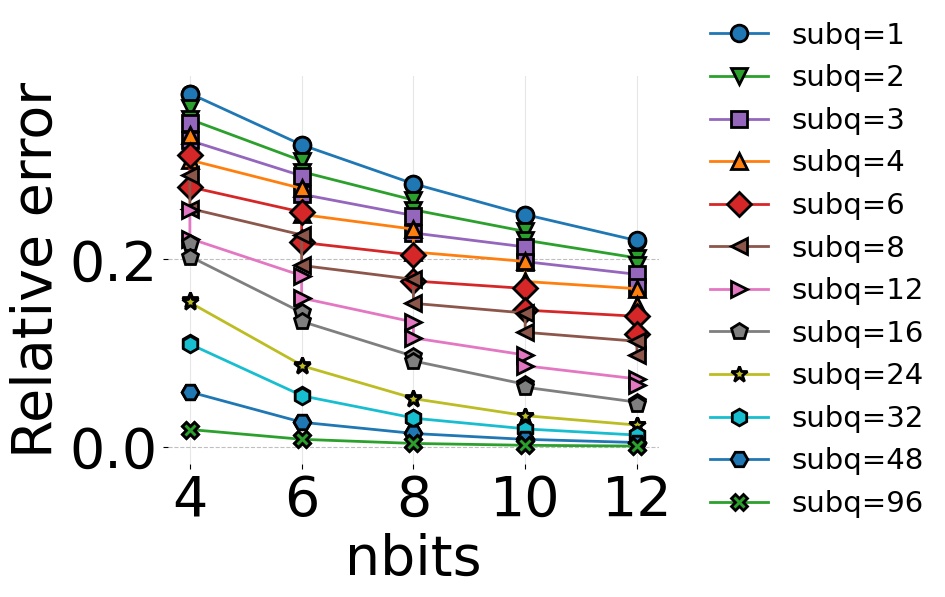

In [116]:
# Color and marker palettes (will be dynamically assigned based on data)
# These are ordered lists that will be cycled through based on unique values in the data
COLOR_PALETTE = [
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red",
    "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan",
    "tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red"
]

MARKER_PALETTE = [
    "o", "v", "s", "^", "D", "<", ">", "p", "*", "h", "H", "X", "d", "P", "8"
]

def create_dynamic_color_map(unique_values):
    """Create a color map dynamically based on unique values in the data."""
    sorted_values = sorted(unique_values)
    color_map = {}
    for i, val in enumerate(sorted_values):
        color_map[val] = COLOR_PALETTE[i % len(COLOR_PALETTE)]
    return color_map

def create_dynamic_marker_map(unique_values):
    """Create a marker map dynamically based on unique values in the data."""
    sorted_values = sorted(unique_values)
    marker_map = {}
    for i, val in enumerate(sorted_values):
        marker_map[val] = MARKER_PALETTE[i % len(MARKER_PALETTE)]
    return marker_map


def plot_relerr_vs_x(
    df: pd.DataFrame, 
    x_col: str, 
    x_label: str, 
    y_col: str = "rel_error_mean",
    y_label: str = None,
    methods: list = None,
    datasets: list = None,
    ylim: tuple = None,
    group_by: str = None,
    output_dir: Path = None
):
    """
    Plot `y_col` vs `x_col`, with separate figures per method and dataset.
    
    Grouping logic:
    - When x_col is 'n_subquantizers': separate curves by nbits.
    - When x_col is 'nbits': separate curves by n_subquantizers.
    - When x_col is 'bits_per_vector': grouping is controlled by BITS_PER_VECTOR_GROUPING config
      (can be "nbits" or "n_subquantizers").
    
    Args:
        df: DataFrame with results
        x_col: Column name to plot on x-axis
        x_label: Display label for x-axis
        y_col: Column name to plot on y-axis (default: "rel_error_mean")
        y_label: Display label for y-axis (if None, auto-generated from y_col)
        methods: List of methods to plot (if None, uses all available)
        datasets: List of datasets to plot (if None, uses all available)
        ylim: Optional tuple (ymin, ymax) to set y-axis limits (if None, uses auto)
        group_by: Optional override for grouping ("nbits" or "n_subquantizers"). If None, uses default logic.
        output_dir: Directory to save plots
    """
    if methods is None:
        methods = sorted(df["method"].unique())
    if datasets is None:
        datasets = sorted(df["dataset"].unique())
    
    if output_dir is None:
        output_dir = Path("./../../experiments/plots/relerr_cpp")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Determine grouping variable based on x_col (or use group_by if provided)
    if group_by is not None:
        # Override default grouping with explicit group_by parameter
        if group_by == "nbits":
            group_col = "nbits"
            group_label_prefix = "nbits="
        elif group_by == "n_subquantizers":
            group_col = "n_subquantizers"
            group_label_prefix = "subq="
        else:
            raise ValueError(f"group_by must be 'nbits' or 'n_subquantizers', got {group_by}")
    elif x_col == "n_subquantizers":
        group_col = "nbits"
        group_label_prefix = "nbits="
    elif x_col == "nbits":
        group_col = "n_subquantizers"
        group_label_prefix = "subq="
    elif x_col == "bits_per_vector":
        # Use configuration to determine grouping
        if BITS_PER_VECTOR_GROUPING == "nbits":
            group_col = "nbits"
            group_label_prefix = "nbits="
        else:  # default to n_subquantizers
            group_col = "n_subquantizers"
            group_label_prefix = "subq="
    else:
        # For other columns, default to grouping by nbits
        group_col = "nbits"
        group_label_prefix = "nbits="
    
    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].copy()
            if sub.empty:
                continue
            
            # Create dynamic color and marker maps based on actual data values
            unique_group_values = sorted(sub[group_col].unique())
            color_map = create_dynamic_color_map(unique_group_values)
            marker_map = create_dynamic_marker_map(unique_group_values)
            
            # Create figure (using default size from rcParams)
            fig, ax = plt.subplots()
            
            # Group by the grouping column and plot each group
            grouped = sub.groupby(group_col)
            for group_val, group_df in grouped:
                # Sort by x_col for proper line plotting
                group_df_sorted = group_df.sort_values(x_col)
                
                # Get color and marker for this group
                color = color_map[group_val]
                marker = marker_map[group_val]
                
                # Plot line without error bars
                ax.plot(
                    group_df_sorted[x_col],
                    group_df_sorted[y_col],
                    label=f"{group_label_prefix}{group_val}",
                    color=color,
                    marker=marker,
                    markersize=12,
                    linewidth=2,
                    markeredgewidth=2,
                    markeredgecolor="black",
                )
            
            ax.set_xlabel(x_label, fontsize=40)
            # Set y-axis label - use provided y_label or generate from y_col
            if y_label is None:
                if y_col == "rel_error_mean":
                    y_label = "Relative error"
                elif y_col == "adc_time_s":
                    y_label = "ADC time (seconds)"
                elif y_col == "train_time_s":
                    y_label = "Training time (seconds)"
                elif y_col == "distance_table_time_s":
                    y_label = "Distance table time (seconds)"
                elif y_col == "encoding_time_s":
                    y_label = "Encoding time (seconds)"
                else:
                    y_label = y_col.replace("_", " ").title()
            ax.set_ylabel(y_label, fontsize=40)
            # No title - method and dataset are specified as inputs
            ax.tick_params(labelsize=40)
            
            # Set y-axis limits if specified
            if ylim is not None:
                ax.set_ylim(ylim)
            # Use log scale for subquantizers (like reference image)
            # You can add other columns here if you want log scale
            if x_col == "n_subquantizers":
                ax.set_xscale("log")
                # Get unique subquantizer values from data and select 3-4 evenly spaced ticks
                unique_subq = sorted(sub[x_col].unique())
                if len(unique_subq) > 4:
                    # Select 4 evenly spaced indices
                    indices = np.linspace(0, len(unique_subq) - 1, 4, dtype=int)
                    tick_values = [unique_subq[i] for i in indices]
                else:
                    tick_values = unique_subq
                # Store tick values to reapply after tight_layout
                tick_values_to_use = tick_values
            elif x_col == "nbits":
                # Explicitly set ticks to show all unique nbits values (including 4)
                unique_nbits = sorted(sub[x_col].unique())
                tick_values_to_use = unique_nbits
                ax.set_xticks(unique_nbits)
            else:
                # Limit to 3-4 ticks for linear axes
                # Check if values are integers
                unique_vals = sorted(sub[x_col].unique())
                if all(isinstance(v, (int, np.integer)) or (isinstance(v, float) and v.is_integer()) for v in unique_vals):
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
                else:
                    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
                tick_values_to_use = None
            
            # Grid styling like reference
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Place legend outside plot when nbits or bits_per_vector is x-axis to avoid interference
            if x_col in ["nbits", "bits_per_vector"]:
                ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.05, 0.5))
            else:
                ax.legend(frameon=False, loc='best')
            
            # Apply tight_layout first
            plt.tight_layout()
            
            # Re-apply ticks for log scale after tight_layout to ensure they're preserved
            if x_col == "n_subquantizers" and tick_values_to_use is not None:
                ax.set_xticks(tick_values_to_use)
                ax.set_xticklabels([int(x) for x in tick_values_to_use])
            
            # Save figure with consistent DPI
            safe_method = method.lower()
            safe_dataset = dataset.lower()
            safe_x = x_col.replace("_", "")
            # Include y_col in filename if it's not the default
            if y_col != "rel_error_mean":
                safe_y = y_col.replace("_", "")
                savepath = output_dir / f"{safe_y}_{safe_method}_{safe_dataset}_{safe_x}.pdf"
            else:
                savepath = output_dir / f"relerr_{safe_method}_{safe_dataset}_{safe_x}.pdf"
            # fig.savefig(savepath, bbox_inches='tight', dpi=300)
            fig.savefig(savepath, dpi=300)
            
            print(f"Saved figure to {savepath}")
            
            plt.show()
            plt.close(fig)


def plot_bar_chart(
    df: pd.DataFrame,
    x_col: str,
    x_label: str,
    y_col: str = "train_time_s",
    y_label: str = None,
    methods: list = None,
    datasets: list = None,
    group_by: str = None,
    output_dir: Path = None
):
    """
    Plot bar chart (bin-style) for y_col vs x_col, with separate figures per method and dataset.
    
    Args:
        df: DataFrame with results
        x_col: Column name to plot on x-axis (will be grouped into bars)
        x_label: Display label for x-axis
        y_col: Column name to plot on y-axis (default: "train_time_s")
        y_label: Display label for y-axis (if None, auto-generated from y_col)
        methods: List of methods to plot (if None, uses all available)
        datasets: List of datasets to plot (if None, uses all available)
        group_by: "nbits" or "n_subquantizers" - how to group the bars (different bars for each group)
        output_dir: Directory to save plots
    """
    if methods is None:
        methods = sorted(df["method"].unique())
    if datasets is None:
        datasets = sorted(df["dataset"].unique())
    
    if output_dir is None:
        output_dir = Path("./../../experiments/plots/relerr_cpp")
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Determine grouping variable
    if group_by is None:
        # Default: group by the other variable (if x_col is nbits, group by n_subquantizers)
        if x_col == "nbits":
            group_col = "n_subquantizers"
            group_label_prefix = "subq="
        elif x_col == "n_subquantizers":
            group_col = "nbits"
            group_label_prefix = "nbits="
        else:
            # Default to grouping by nbits
            group_col = "nbits"
            group_label_prefix = "nbits="
    else:
        if group_by == "nbits":
            group_col = "nbits"
            group_label_prefix = "nbits="
        elif group_by == "n_subquantizers":
            group_col = "n_subquantizers"
            group_label_prefix = "subq="
        else:
            raise ValueError(f"group_by must be 'nbits' or 'n_subquantizers', got {group_by}")
    
    for method in methods:
        for dataset in datasets:
            sub = df[(df["method"] == method) & (df["dataset"] == dataset)].copy()
            if sub.empty:
                continue
            
            # Create figure
            fig, ax = plt.subplots()
            
            # Get unique x_col and group_col values
            unique_x_vals = sorted(sub[x_col].unique())
            unique_group_vals = sorted(sub[group_col].unique())
            
            # Number of groups (x_col values) and bars per group (group_col values)
            n_groups = len(unique_x_vals)
            n_bars_per_group = len(unique_group_vals)
            
            # Set up bar positions for grouped bars
            bar_width = 0.8 / n_bars_per_group
            x_positions = np.arange(n_groups)
            
            # Color palette for different group_col values - same color for same group_col value
            colors = plt.cm.tab10(np.linspace(0, 1, n_bars_per_group))
            
            # Plot bars for each group_col value
            for i, group_val in enumerate(unique_group_vals):
                # Calculate y values for this group_col value across all x_col values
                y_vals = []
                for x_val in unique_x_vals:
                    # Get data for this specific x_col and group_col combination
                    data = sub[(sub[x_col] == x_val) & (sub[group_col] == group_val)]
                    if not data.empty:
                        # Use the actual value (not averaged) - if multiple rows exist, take mean
                        y_val = data[y_col].iloc[0] if len(data) == 1 else data[y_col].mean()
                        y_vals.append(y_val)
                    else:
                        y_vals.append(0)
                
                # Calculate bar positions (offset for grouped bars)
                bar_positions = x_positions + i * bar_width
                
                # Plot bars - all bars with same group_col value get the same color
                ax.bar(
                    bar_positions,
                    y_vals,
                    width=bar_width,
                    label=f"{group_label_prefix}{group_val}",
                    color=colors[i],
                    edgecolor="black",
                    linewidth=2,
                    alpha=0.8
                )
            
            # Set labels and styling
            ax.set_xlabel(x_label, fontsize=40)
            if y_label is None:
                if y_col == "train_time_s":
                    y_label = "Training time (seconds)"
                elif y_col == "adc_time_s":
                    y_label = "ADC time (seconds)"
                elif y_col == "distance_table_time_s":
                    y_label = "Distance table time (seconds)"
                else:
                    y_label = y_col.replace("_", " ").title()
            ax.set_ylabel(y_label, fontsize=40)
            ax.tick_params(labelsize=40)
            
            # Set x-axis ticks at the center of each group
            ax.set_xticks(x_positions)
            ax.set_xticklabels([int(x) if isinstance(x, (int, np.integer)) or (isinstance(x, float) and x.is_integer()) else x 
                               for x in unique_x_vals])
            
            # Add legend
            # ax.legend(frameon=False, fontsize=30)
            
            # Grid styling - match reference image style
            ax.grid(alpha=0.8, axis='y', linestyle='--')
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Apply tight_layout
            plt.tight_layout()
            
            # Save figure
            safe_method = method.lower()
            safe_dataset = dataset.lower()
            safe_x = x_col.replace("_", "")
            safe_y = y_col.replace("_", "")
            savepath = output_dir / f"bar_{safe_y}_{safe_method}_{safe_dataset}_{safe_x}.pdf"
            # fig.savefig(savepath, bbox_inches='tight', dpi=300)
            fig.savefig(savepath, dpi=300)
            print(f"Saved figure to {savepath}")
            
            plt.show()
            plt.close(fig)


def plot_opq_vs_pq_rot_percent(
    df: pd.DataFrame,
    dataset: str,
    nbits_list,
    n_subquantizers_list,
    output_dir: Path = None,
    figsize: tuple = (10, 6),
    n_bins: int = 20,
):
    """
    Plot relative error vs % of (max_opq_rot_train_samples / rot_train_sz), averaged across
    all (nbits, n_subquantizers) in nbits_list x n_subquantizers_list.
    PQ: horizontal line = mean rel_error over those pairs.
    OPQ: curve = for each x (pct_rot bin), mean rel_error over all selected pairs in that bin.
    Shade red where OPQ is above PQ (worse), green where OPQ is below PQ (better).
    nbits_list and n_subquantizers_list can be lists or single ints (converted to list).
    """
    if output_dir is None:
        output_dir = Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    nbits_list = [nbits_list] if np.isscalar(nbits_list) else list(nbits_list)
    n_subquantizers_list = [n_subquantizers_list] if np.isscalar(n_subquantizers_list) else list(n_subquantizers_list)

    for col in ["rot_train_sz", "max_opq_rot_train_samples"]:
        if col not in df.columns:
            raise ValueError(
                f"DataFrame must contain OPQ columns 'rot_train_sz' and 'max_opq_rot_train_samples'. Missing: {col}"
            )

    # PQ: average rel_error over all (dataset, nbits, n_subquantizers) in the lists
    pq = df[(df["method"] == "PQ") & (df["dataset"] == dataset) & (df["nbits"].isin(nbits_list)) & (df["n_subquantizers"].isin(n_subquantizers_list))]
    if pq.empty:
        raise ValueError(f"No PQ data for dataset={dataset}, nbits in {nbits_list}, n_subquantizers in {n_subquantizers_list}")
    pq_err = float(pq["rel_error_mean"].mean())

    # OPQ: all rows for (dataset, nbits, n_subquantizers) in the lists; compute pct_rot
    opq = df[(df["method"] == "OPQ") & (df["dataset"] == dataset) & (df["nbits"].isin(nbits_list)) & (df["n_subquantizers"].isin(n_subquantizers_list))].copy()
    opq = opq.dropna(subset=["rot_train_sz", "max_opq_rot_train_samples"])
    if opq.empty:
        raise ValueError(f"No OPQ data for dataset={dataset}, nbits in {nbits_list}, n_subquantizers in {n_subquantizers_list}")
    opq["pct_rot"] = 100.0 * opq["max_opq_rot_train_samples"] / opq["rot_train_sz"]

    # Bin pct_rot and average rel_error_mean in each bin (one curve across all (nbits, M))
    pct_min, pct_max = opq["pct_rot"].min(), opq["pct_rot"].max()
    bins = np.linspace(pct_min, pct_max, n_bins + 1)
    opq["_bin"] = pd.cut(opq["pct_rot"], bins=bins, include_lowest=True)
    agg = opq.groupby("_bin", observed=True).agg({"pct_rot": "mean", "rel_error_mean": "mean"}).reset_index()
    x = agg["pct_rot"].values
    y_opq = agg["rel_error_mean"].values
    y_pq = np.full_like(x, pq_err)

    fig, ax = plt.subplots(figsize=figsize)
    # Shaded regions: green where OPQ > PQ (worse), red where OPQ < PQ (better)
    # Red = OPQ worse (above PQ), green = OPQ better (below PQ)
    ax.fill_between(x, y_pq, y_opq, where=(y_opq >= y_pq), color="red", alpha=0.35, interpolate=True)
    ax.fill_between(x, y_pq, y_opq, where=(y_opq < y_pq), color="green", alpha=0.35, interpolate=True)
    # Custom markers and colors from notebook palette (consistent with other figures)
    ax.plot(x, y_pq, color=COLOR_PALETTE[0], linewidth=2, marker="o", markersize=12, markeredgecolor="black", markeredgewidth=2, label="PQ")
    ax.plot(x, y_opq, color=COLOR_PALETTE[1], linewidth=2, marker="s", markersize=12, markeredgecolor="black", markeredgewidth=2, label="OPQ")
    ax.set_xlabel("% data used to learn R", fontsize=40)
    ax.set_ylabel("Relative error", fontsize=40)
    ax.tick_params(labelsize=40)
    # Widen y-axis for a better view (add ~15% padding above and below data range)
    y_lo = min(pq_err, y_opq.min())
    y_hi = max(pq_err, y_opq.max())
    pad = max((y_hi - y_lo) * 0.15, 0.005)
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.grid(alpha=0.8, axis="y", linestyle="--")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, loc="best", fontsize=21)
    plt.tight_layout()
    suffix = f"M{min(n_subquantizers_list)}-{max(n_subquantizers_list)}_nbits{min(nbits_list)}-{max(nbits_list)}" if (len(n_subquantizers_list) > 1 or len(nbits_list) > 1) else f"M{n_subquantizers_list[0]}_nbits{nbits_list[0]}"
    savepath = output_dir / f"opq_vs_pq_rot_pct_{dataset}_{suffix}.pdf"
    fig.savefig(savepath, dpi=300)
    print(f"Saved {savepath}")
    plt.show()
    plt.close(fig)


def plot_opq_vs_pq_train_time_rot_percent(
    df: pd.DataFrame,
    dataset: str,
    nbits_list,
    n_subquantizers_list,
    output_dir: Path = None,
    figsize: tuple = (10, 6),
    n_bins: int = 20,
):
    """
    Plot training time vs % of data used to learn R, averaged across
    all (nbits, n_subquantizers) in nbits_list x n_subquantizers_list.
    PQ: horizontal line = mean train_time_s over those pairs.
    OPQ: curve = train_time_s + opq_train_time_s per run, binned by pct_rot and averaged.
    Same x-axis and averaging logic as plot_opq_vs_pq_rot_percent.
    """
    if output_dir is None:
        output_dir = Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    nbits_list = [nbits_list] if np.isscalar(nbits_list) else list(nbits_list)
    n_subquantizers_list = [n_subquantizers_list] if np.isscalar(n_subquantizers_list) else list(n_subquantizers_list)

    for col in ["rot_train_sz", "max_opq_rot_train_samples", "train_time_s"]:
        if col not in df.columns:
            raise ValueError(f"DataFrame must contain '{col}'. Missing: {col}")

    # PQ: average train_time_s over all (dataset, nbits, n_subquantizers) in the lists
    pq = df[(df["method"] == "PQ") & (df["dataset"] == dataset) & (df["nbits"].isin(nbits_list)) & (df["n_subquantizers"].isin(n_subquantizers_list))]
    if pq.empty:
        raise ValueError(f"No PQ data for dataset={dataset}, nbits in {nbits_list}, n_subquantizers in {n_subquantizers_list}")
    pq_time = float(pq["train_time_s"].mean())

    # OPQ: train_time_s + opq_train_time_s (use train_time_s only if opq_train_time_s missing)
    opq = df[(df["method"] == "OPQ") & (df["dataset"] == dataset) & (df["nbits"].isin(nbits_list)) & (df["n_subquantizers"].isin(n_subquantizers_list))].copy()
    opq = opq.dropna(subset=["rot_train_sz", "max_opq_rot_train_samples", "train_time_s"])
    if opq.empty:
        raise ValueError(f"No OPQ data for dataset={dataset}, nbits in {nbits_list}, n_subquantizers in {n_subquantizers_list}")
    if "opq_train_time_s" in opq.columns:
        opq["total_train_time_s"] = opq["train_time_s"] + opq["opq_train_time_s"].fillna(0)
    else:
        opq["total_train_time_s"] = opq["train_time_s"]
    opq["pct_rot"] = 100.0 * opq["max_opq_rot_train_samples"] / opq["rot_train_sz"]

    # Bin pct_rot and average total_train_time_s in each bin
    pct_min, pct_max = opq["pct_rot"].min(), opq["pct_rot"].max()
    bins = np.linspace(pct_min, pct_max, n_bins + 1)
    opq["_bin"] = pd.cut(opq["pct_rot"], bins=bins, include_lowest=True)
    agg = opq.groupby("_bin", observed=True).agg({"pct_rot": "mean", "total_train_time_s": "mean"}).reset_index()
    x = agg["pct_rot"].values
    y_opq = agg["total_train_time_s"].values
    y_pq = np.full_like(x, pq_time)

    fig, ax = plt.subplots(figsize=figsize)
    ax.fill_between(x, y_pq, y_opq, where=(y_opq >= y_pq), color="red", alpha=0.35, interpolate=True)
    ax.fill_between(x, y_pq, y_opq, where=(y_opq < y_pq), color="green", alpha=0.35, interpolate=True)
    ax.plot(x, y_pq, color=COLOR_PALETTE[0], linewidth=2, marker="o", markersize=12, markeredgecolor="black", markeredgewidth=2, label="PQ")
    ax.plot(x, y_opq, color=COLOR_PALETTE[1], linewidth=2, marker="s", markersize=12, markeredgecolor="black", markeredgewidth=2, label="OPQ")
    ax.set_xlabel("% data used to learn R", fontsize=40)
    ax.set_ylabel("Train time (s)", fontsize=40)
    ax.tick_params(labelsize=40)
    y_lo = min(pq_time, y_opq.min())
    y_hi = max(pq_time, y_opq.max())
    pad = max((y_hi - y_lo) * 0.15, 1.0)
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.grid(alpha=0.8, axis="y", linestyle="--")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, loc="best", fontsize=21)
    plt.tight_layout()
    suffix = f"M{min(n_subquantizers_list)}-{max(n_subquantizers_list)}_nbits{min(nbits_list)}-{max(nbits_list)}" if (len(n_subquantizers_list) > 1 or len(nbits_list) > 1) else f"M{n_subquantizers_list[0]}_nbits{nbits_list[0]}"
    savepath = output_dir / f"opq_vs_pq_train_time_rot_pct_{dataset}_{suffix}.pdf"
    fig.savefig(savepath, dpi=300)
    print(f"Saved {savepath}")
    plt.show()
    plt.close(fig)


# Generate plots based on configuration
for x_col, x_label in X_COLUMNS_TO_PLOT:
    # Check if column exists in dataframe
    if x_col not in relerr_df.columns:
        print(f"Warning: Column '{x_col}' not found in dataframe. Skipping...")
        continue
    
    # Get ylim for this x-axis column if specified
    ylim = YLIM_CONFIG.get(x_col, None)
    
    print(f"\n{'='*60}")
    print(f"Plotting: Relative error vs {x_label}")
    print(f"Methods: {METHODS_TO_PLOT}, Datasets: {DATASETS_TO_PLOT}")
    if ylim is not None:
        print(f"Y-axis limits: {ylim}")
    print(f"{'='*60}\n")
    plot_relerr_vs_x(
        relerr_df, 
        x_col, 
        x_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        ylim=ylim,
        output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    )

# Generate additional plots with different y-axis columns
for x_col, x_label, y_col, y_label, group_by in ADDITIONAL_PLOTS:
    # Check if columns exist in dataframe
    if x_col not in relerr_df.columns:
        print(f"Warning: Column '{x_col}' not found in dataframe. Skipping...")
        continue
    if y_col not in relerr_df.columns:
        print(f"Warning: Column '{y_col}' not found in dataframe. Skipping...")
        continue
    
    # Get ylim for this x-axis column if specified
    ylim = YLIM_CONFIG.get(x_col, None)
    
    print(f"\n{'='*60}")
    print(f"Plotting: {y_label} vs {x_label} (grouped by {group_by})")
    print(f"Methods: {METHODS_TO_PLOT}, Datasets: {DATASETS_TO_PLOT}")
    if ylim is not None:
        print(f"Y-axis limits: {ylim}")
    print(f"{'='*60}\n")
    plot_relerr_vs_x(
        relerr_df, 
        x_col, 
        x_label,
        y_col=y_col,
        y_label=y_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        ylim=ylim,
        group_by=group_by,
        output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    )

In [117]:
# Generate bar plots (bin-style plots) for training time
for x_col, x_label, y_col, y_label, average_over in BAR_PLOTS:
    # Check if columns exist in dataframe
    if x_col not in relerr_df.columns:
        print(f"Warning: Column '{x_col}' not found in dataframe. Skipping...")
        continue
    if y_col not in relerr_df.columns:
        print(f"Warning: Column '{y_col}' not found in dataframe. Skipping...")
        continue
    
    print(f"\n{'='*60}")
    print(f"Plotting bar chart: {y_label} vs {x_label} (averaged over {average_over})")
    print(f"Methods: {METHODS_TO_PLOT}, Datasets: {DATASETS_TO_PLOT}")
    print(f"{'='*60}\n")
    plot_bar_chart(
        relerr_df, 
        x_col, 
        x_label,
        y_col=y_col,
        y_label=y_label,
        methods=METHODS_TO_PLOT,
        datasets=DATASETS_TO_PLOT,
        group_by=average_over,
        output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures")
    )

Saved /data/cpanourg/2-hdvc/results/relerr_cpp/figures/opq_vs_pq_rot_pct_deep_M1-96_nbits4-12.pdf


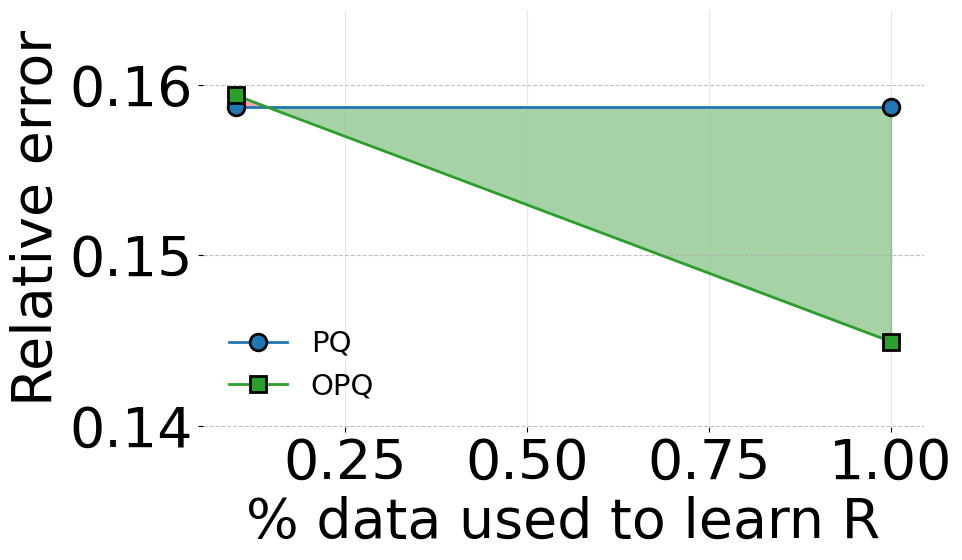

In [118]:
# OPQ vs PQ: relative error vs % of rot_train used, averaged across (nbits, n_subquantizers) in the lists
# Requires OPQ results with columns rot_train_sz and max_opq_rot_train_samples (e.g. from train_opq outputs).
OPQ_VS_PQ_DATASET = "deep"
OPQ_VS_PQ_NBITS = [4, 6, 8, 10, 12 ]   # list of nbits to average over
OPQ_VS_PQ_M = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 96]   # list of n_subquantizers to average over

plot_opq_vs_pq_rot_percent(
    relerr_df,
    dataset=OPQ_VS_PQ_DATASET,
    nbits_list=OPQ_VS_PQ_NBITS,
    n_subquantizers_list=OPQ_VS_PQ_M,
    output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures"),
    figsize=(10, 6),
    n_bins=20,
)

Saved /data/cpanourg/2-hdvc/results/relerr_cpp/figures/opq_vs_pq_train_time_rot_pct_deep_M1-96_nbits4-12.pdf


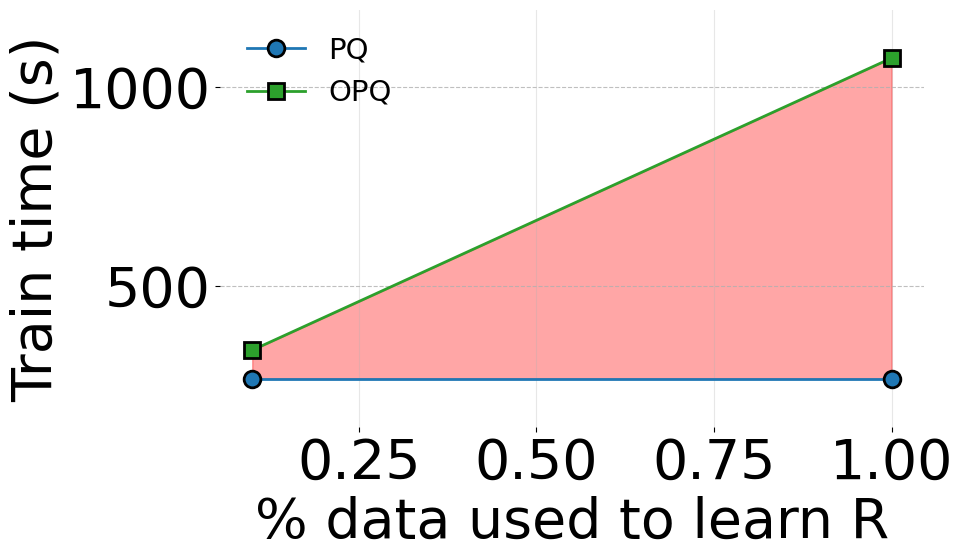

In [119]:
# OPQ vs PQ: training time vs % of data used to learn R (same lists as above, separate function)
# PQ = train_time_s; OPQ = train_time_s + opq_train_time_s; averaged over OPQ_VS_PQ_NBITS and OPQ_VS_PQ_M
plot_opq_vs_pq_train_time_rot_percent(
    relerr_df,
    dataset=OPQ_VS_PQ_DATASET,
    nbits_list=OPQ_VS_PQ_NBITS,
    n_subquantizers_list=OPQ_VS_PQ_M,
    output_dir=Path("/data/cpanourg/2-hdvc/results/relerr_cpp/figures"),
    figsize=(10, 6),
    n_bins=20,
)

In [14]:
# 